## Consultas SQL desde una base Local/on-site SQLite desde jupyter notebook

##### Para fines de la prueba, se utiliza SQLite para crear la base de datos a la que se puedan hacer consultas.
SQLite es una base de datos relacional ligera que se almacena en un solo archivo y no necesita servidor, por lo que es ideal para análisis en local.

#### Luego de crear la base de datos importando la data de las tablas de excel suministradas, se realiza:

##### 1. crear la conexión a la base de datos que tiene el nombre de 'prueba_sql.db'

In [71]:
import sqlite3
import pandas as pd

# Conecxión a la base de datos
conn = sqlite3.connect("prueba_sql.db")


#### 2. Realizar las querys o consultas de la prueba SQL (para lograr hacer consultas totalmente SQL se cuenta con la extensión Ipython-sql. luego se convierten las consultas a df para ser mostradas con formato pandas (tabla tipo dataframe) y finalmente visualizaciones a través de gráficas con matplotlib):

#### Preguntas:
##### 2.1 - Selecciona el nombre del almacén, el nombre del municipio y el valor total de facturas para cada almacén:
##### Se tiene en cuenta las siguientes tablas (a traves de JOINs):
##### . almacenes para traer el nombre de almacen con el almacencodigo
##### . personas para traer el codigo del municipio con el personacodigo
##### . municipios para traer el nombre del municipio con municipiocodigo
##### usando como base la tabla creditos con FROM creditos
##### para obtener valorfactura_total, se aplica SUM() a la columna valorfactura de la tabla creditos, agrupando la data por nombre de almacen y de municipio:

In [74]:
query = """
SELECT 
    a.nombre AS almacen,
    m.Nombre AS municipio,
    SUM(CAST(c.valorfactura AS INTEGER)) AS valorfactura_total
FROM creditos c
JOIN almacenes a ON c.almacencodigo = a.almacencodigo
JOIN personas p ON c.personacodigo = p.personacodigo
JOIN municipios m ON p.municipiocodigo = m.MunicipioCodigo
GROUP BY a.nombre, m.Nombre
ORDER BY valorfactura_total DESC;
"""

df = pd.read_sql_query(query, conn)

# Mostrar como dataframe la consulta (primeros 10 resultados)
df.head(10)


,almacen,municipio,valorfactura_total
0,Totto Medellin Junin,Medellin,579171267
1,Calzatodo CC Los Molinos,Medellin,132764672
2,Calzatodo CC Unicentro,Medellin,111704756
3,Calzatodo Junin,Medellin,107345589
4,Color Blue CC San Diego,Medellin,70874560
5,Studio F CC Premium Plaza,Medellin,68141354
6,Trust Coltejer,Medellin,63629255
7,Calzatodo CC San Diego II,Medellin,57394632
8,Chopper Unicentro,Medellin,54696685
9,Pilatos Project Molinos,Medellin,54578241


##### Teniendo las capacidades de un jupyter notebook, se puede incluir visualizaciones en caso de necesitarlas o querer tener una visual rápida de la data, por ejemplo:


<Axes: xlabel='almacen'>

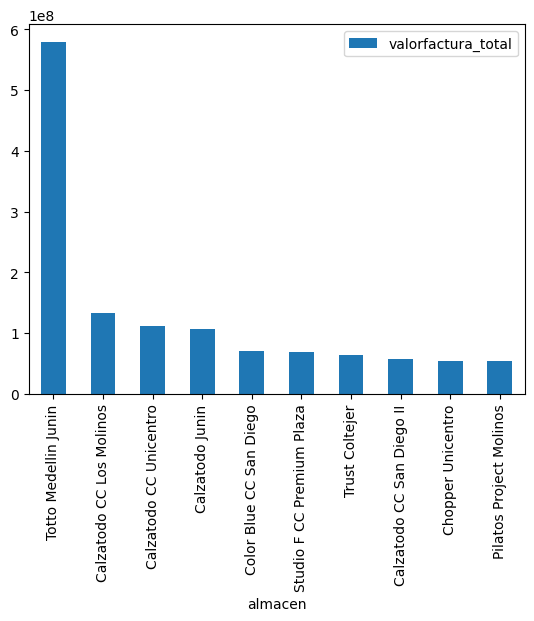

In [13]:

df.head(10).plot(kind='bar', x='almacen', y='valorfactura_total')


##### 2.2 - Calcula el valorfactura promedio, la suma de saldocapital y la suma de saldofinanciacion por departamento.

##### Se tiene en cuenta las tablas:
##### . personas para traer el codigo departamento con personacodigo
##### . departamentos para traer el nombre del departamento con departamentocodigo

##### Usando como base la tabla creditos que contiene valorfactura, saldocapital y saldofinanciacion
##### Las funciones de agregación utilizadas son SUM() para sumas y AVG() para promedios.


In [ ]:
query = """
SELECT 
    d.Nombre AS departamento,
    AVG(c.valorfactura) AS valorfactura_promedio,
    SUM(c.saldocapital) AS saldocapital_total,
    SUM(c.saldofinanciacion) AS saldofinanciacion_total
FROM creditos c
JOIN personas p ON c.personacodigo = p.personacodigo
JOIN departamentos d ON p.departamentocodigo = d.Codigo
GROUP BY d.Nombre
ORDER BY valorfactura_promedio DESC;
"""

df_departamento = pd.read_sql_query(query, conn)


# Mostrar todos los números en formato normal (float), para evitar notación científica
pd.set_option('display.float_format', '{:,.2f}'.format)


# Mostrar la consulta como dataframe (primeros 10 resultados o filas)
df_departamento.head(10)  



,departamento,valorfactura_promedio,saldocapital_total,saldofinanciacion_total
0,Huila,"8,267,205.00","3,044,924.05","48,040.46"
1,Valle Del Cauca,"3,890,789.50","1,645,245.00","112,751.26"
2,Meta,"3,627,088.00","216,000.00","10,769.15"
3,Bogotá D.c.,"2,825,108.00","2,076,914.99","108,932.57"
4,Norte De Santander,"2,698,779.00","215,000.00","15,587.87"
5,Risaralda,"2,136,320.60","4,763,605.99","315,290.38"
6,Antioquia,"1,742,258.34","1,227,297,794.71","71,038,845.27"
7,Santander,"1,637,959.89","6,124,164.44","293,290.00"
8,Caqueta,"1,505,847.00","498,846.00","27,674.01"
9,Departamento Error,"980,729.00","695,357.99","25,448.05"


<Axes: xlabel='departamento'>

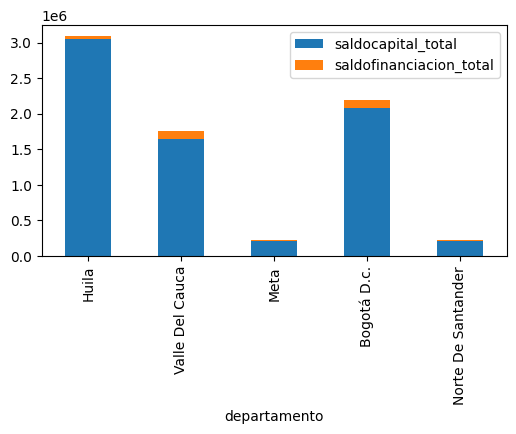

In [40]:
# Ejemplo gráfica barras apiladas para 5 primeros elementos
df_departamento.head(5).plot(
    kind='bar', 
    x='departamento', 
    y=['saldocapital_total','saldofinanciacion_total'], 
    stacked=True, 
    figsize=(6,3)
)



##### 2.3 Encuentra el departamento con el valorfactura total más alto.


##### un CTE es una tabla temporal, que se utiliza para que las consultas sean más claras y evitar realizar tantas subconsultas. Se utiliza  WITH para la creación de dicha tabla

##### En este caso se crea la tabla temporal 'totales_por_departamentos.

In [105]:
query = """
WITH totales_por_departamento AS (
    SELECT 
        d.Nombre AS departamento, 
        SUM(c.valorfactura) AS valorfactura_total
    FROM creditos c
    JOIN personas p 
        ON c.personacodigo = p.personacodigo
    JOIN departamentos d 
        ON p.departamentocodigo = d.Codigo
    GROUP BY d.Nombre
)
SELECT 
    departamento,
    valorfactura_total
FROM totales_por_departamento
ORDER BY valorfactura_total DESC
LIMIT 1;
"""


df = pd.read_sql_query(query, conn)

print("Departamento con mayor valorfactura total:")

df



Departamento con mayor valorfactura total:


,departamento,valorfactura_total
0,Antioquia,"3,406,115,045.00"


##### 2.4 Identifica los 5 almacenes con el mayor porcentaje de créditos de "Alto Riesgo" (donde el saldocapital es mayor al 70% del valorfactura). A parte de mostrar el porcentaje de alto riesgo, se agregan las columnas 'total_credito' y 'creditos_alto_riesgo', para visualizar la razón de por qué son los almacenes con mayor porcentaje de alto riesgo. 

In [84]:

# Conexión a la base de datos
conn = sqlite3.connect("prueba_sql.db")

# Query
query = """
SELECT 
    a.almacencodigo,
    a.nombre AS nombre_almacen,
    COUNT(*) AS total_creditos,
    SUM(
        CASE 
            WHEN c.saldocapital > 0.70 * c.valorfactura THEN 1
            ELSE 0
        END
    ) AS creditos_alto_riesgo,
    ROUND(
        100.0 * SUM(
            CASE 
                WHEN c.saldocapital > 0.70 * c.valorfactura THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS porcentaje_alto_riesgo
FROM creditos c
JOIN almacenes a 
    ON c.almacencodigo = a.almacencodigo
GROUP BY a.almacencodigo, a.nombre
ORDER BY porcentaje_alto_riesgo DESC
LIMIT 5;
"""

# Ejecutar consulta
df = pd.read_sql_query(query, conn)

# Mostrar resultados
df


,almacencodigo,nombre_almacen,total_creditos,creditos_alto_riesgo,porcentaje_alto_riesgo
0,21,Over Dressed,1,1,100.00
1,36,Color Blue Tesoro,2,2,100.00
2,58,Yoko CNC 215,1,1,100.00
3,64,Polo San Diego,1,1,100.00
4,78,MultiOpticas Sucre No2,2,2,100.00


Calcula el valorfactura total por departamento y mes, ordenado por año y mes.

In [ ]:

# Query
query = """
SELECT
    d.Codigo AS departamentocodigo,
    d.Nombre AS nombre_departamento,
    strftime('%Y', c.fechacreacion) AS anio,
    strftime('%m', c.fechacreacion) AS mes,
    SUM(c.valorfactura) AS valorfactura_total
FROM creditos c
JOIN personas p 
    ON c.personacodigo = p.personacodigo
JOIN departamentos d 
    ON p.departamentocodigo = d.Codigo
GROUP BY 
    d.Codigo,
    d.Nombre,
    anio,
    mes
ORDER BY 
    anio,
    mes,
    d.Nombre;
"""

# Ejecutar consulta
df = pd.read_sql_query(query, conn)

# Mostrar resultados (10 primeros)
df.head(10)


,departamentocodigo,nombre_departamento,anio,mes,valorfactura_total
0,4,Antioquia,1999,12,"79,000.00"
1,4,Antioquia,2000,12,"1,524,053.00"
2,4,Antioquia,2001,05,"88,000.00"
3,4,Antioquia,2002,02,"1,111,766.00"
4,4,Antioquia,2002,08,"200,700.00"
5,4,Antioquia,2002,09,"101,000.00"
6,4,Antioquia,2002,10,"1,108,572.00"
7,4,Antioquia,2002,12,"108,700.00"
8,4,Antioquia,2003,07,"2,631,820.00"
9,4,Antioquia,2003,08,"2,558,080.00"


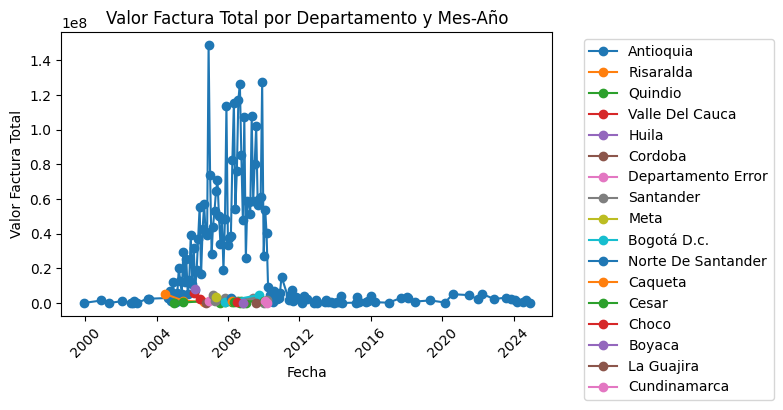

In [ ]:

# Crear columna fecha a partir de año y mes
df['fecha'] = pd.to_datetime(df['anio'] + '-' + df['mes'] + '-01')

# Ordenar por fecha
df = df.sort_values(['fecha', 'nombre_departamento'])


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# ciclo para graficar linea por cada departamento
for depto in df['nombre_departamento'].unique():
    df_depto = df[df['nombre_departamento'] == depto]
    plt.plot(df_depto['fecha'], df_depto['valorfactura_total'], marker='o', label=depto)

plt.title('Valor Factura Total por Departamento y Mes-Año')
plt.xlabel('Fecha')
plt.ylabel('Valor Factura Total')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # leyenda fuera del gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### Identifica los almacenes que consistentemente tienen un valorfactura por debajo del promedio en su respectivo departamento. Consistentemente habla de periodo, por lo tanto se toman los almacenes que en el periodo de tiempo, siempre estuvieron por debajo del promedio del departamento, si al menos en alguno de los meses estuvo por encima del promedio, se descarta.

In [100]:
query = """
WITH facturacion_mensual AS (
    SELECT
        d.Codigo AS departamentocodigo,
        d.Nombre AS departamento,
        a.almacencodigo,
        a.nombre AS almacen,
        strftime('%Y-%m', c.fechacreacion) AS periodo,
        SUM(CAST(c.valorfactura AS INTEGER)) AS valorfactura_mes
    FROM creditos c
    JOIN personas p ON c.personacodigo = p.personacodigo
    JOIN departamentos d ON p.departamentocodigo = d.Codigo
    JOIN almacenes a ON c.almacencodigo = a.almacencodigo
    GROUP BY
        d.Codigo, d.Nombre,
        a.almacencodigo, a.nombre,
        periodo
),
promedios AS (
    SELECT
        departamento,
        almacen,
        departamentocodigo,
        almacencodigo,
        AVG(valorfactura_mes) AS promedio_almacen
    FROM facturacion_mensual
    GROUP BY
        departamento,
        almacen,
        departamentocodigo,
        almacencodigo
),
promedio_departamento AS (
    SELECT
        departamentocodigo,
        AVG(valorfactura_mes) AS promedio_departamento
    FROM facturacion_mensual
    GROUP BY departamentocodigo
),
comparacion AS (
    SELECT
        f.departamento,
        f.almacen,
        f.valorfactura_mes,
        pa.promedio_almacen,
        pd.promedio_departamento,
        CASE
            WHEN f.valorfactura_mes < pd.promedio_departamento THEN 1
            ELSE 0
        END AS debajo_promedio
    FROM facturacion_mensual f
    JOIN promedios pa
        ON f.almacen = pa.almacen
       AND f.departamento = pa.departamento
    JOIN promedio_departamento pd
        ON f.departamentocodigo = pd.departamentocodigo
)
SELECT
    departamento,
    almacen,
    ROUND(promedio_departamento, 2) AS promedio_departamento,
    ROUND(promedio_almacen, 2) AS promedio_almacen
FROM comparacion
GROUP BY
    departamento,
    almacen,
    promedio_departamento,
    promedio_almacen
HAVING
    SUM(debajo_promedio) = COUNT(*)
ORDER BY
    departamento,
    promedio_almacen;
"""


df = pd.read_sql_query(query, conn)
df


,departamento,almacen,promedio_departamento,promedio_almacen
0,Antioquia,Almacen Betico,"2,434,678.37","94,000.00"
1,Antioquia,Mercedes Campuzano CC Puerta del Norte,"2,434,678.37","105,600.00"
2,Antioquia,Calzado Milenio III,"2,434,678.37","110,000.00"
3,Antioquia,Citybags Orquídea Plaza,"2,434,678.37","111,888.00"
4,Antioquia,Everfit Oviedo,"2,434,678.37","124,000.00"
...,...,...,...,...
173,Santander,Roott + Co Los Molinos,"1,637,959.89","1,043,335.00"
174,Santander,Fashion Men Maturin,"1,637,959.89","1,097,195.00"
175,Santander,Mercados Betancur,"1,637,959.89","1,187,718.00"
176,Santander,Chopper Unicentro,"1,637,959.89","1,626,327.00"
